<a href="https://colab.research.google.com/github/Ligohtml/Big_imaging/blob/main/Lucas_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns

sns.set_theme()











FileNotFoundError: [Errno 2] No such file or directory: './data/lucas_dataset_val.csv'

In [2]:
def load_data(fn, src_prefix):
    ''' gets hyperspectral signals using cols starting with src_prefix '''
    # read csv
    df = pd.read_csv(fn)
    # get x points
    src_cols = [col for col in df.columns if col.startswith(src_prefix)]
    x = np.array([float(col[len(src_prefix):]) for col in src_cols])
    # sort x points in increasing order
    pos = np.argsort(x)
    src_cols = [src_cols[cur_pos] for cur_pos in pos]
    # extract x and y values
    src_x = x[pos]
    src_y = df[src_cols].to_numpy()
    # convert to tensor
    src_x = torch.from_numpy(src_x).float()
    src_y = torch.from_numpy(src_y).float()
    # return
    return src_cols, src_x, src_y

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
if __name__ == '__main__':
    # define input file
    data_fn = '/content/drive/MyDrive/Big_imaging/Lesson_6/lucas_dataset_val.csv'
    src_prefix = 'spc.'
    n_components = 0.9
    # read file
    src_cols, src_x, src_y = load_data(data_fn, src_prefix)
    # src_y contains the signals that we need to use

In [8]:
src_y.shape

torch.Size([2000, 4200])

In [9]:
src_x.shape

torch.Size([4200])

In [33]:
pca = PCA(n_components=0.9)
fit=pca.fit_transform(src_y)

In [34]:
fit.shape

(2000, 2)

In [35]:
inversed_y = pca.inverse_transform(fit)

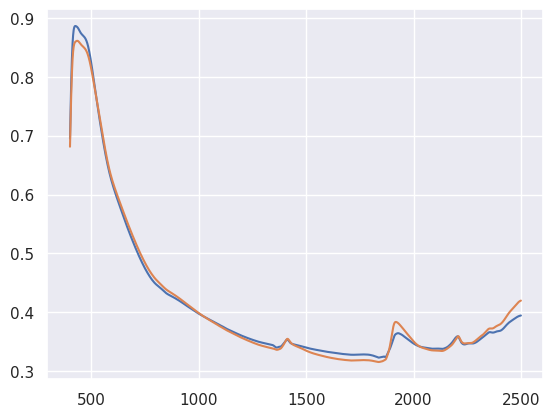

In [36]:
plt.plot(src_x, src_y[0])
plt.plot(src_x, inversed_y[0])

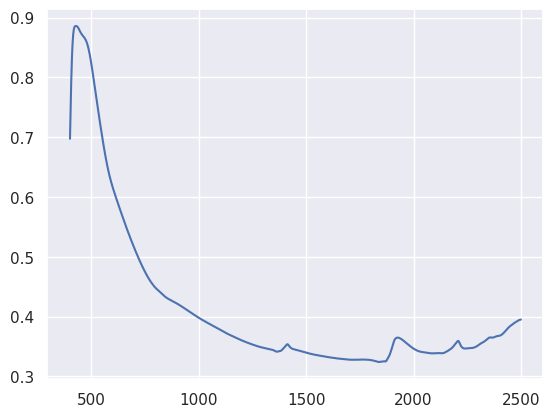

In [32]:
plt.plot(src_x, inversed_y[0])

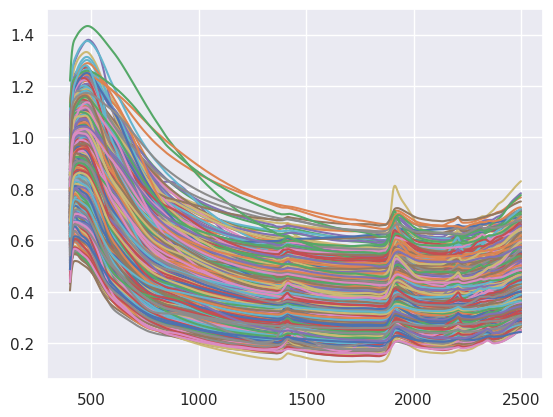

In [38]:
for i in range(src_y.shape[0]):
  plt.plot(src_x, src_y[i])


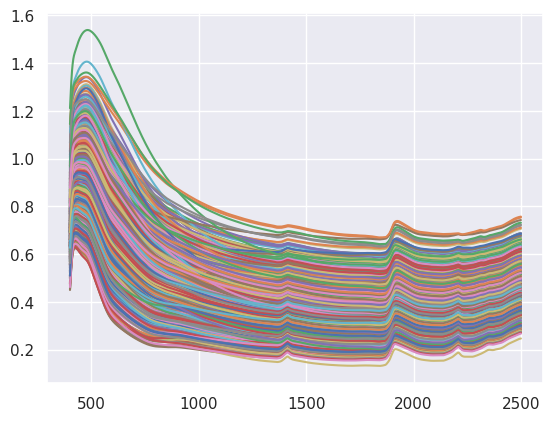

In [37]:
for i in range(src_y.shape[0]):
  plt.plot(src_x, inversed_y[i])


In [40]:
df = pd.DataFrame(src_y)

In [41]:
df.shape

(2000, 4200)

In [42]:
df.mean()

,0
0,0.726553
1,0.735026
2,0.743445
3,0.751784
4,0.760017
...,...
4195,0.440744
4196,0.440826
4197,0.440904
4198,0.440980


In [44]:
df.std()

,0
0,0.111124
1,0.111200
2,0.111288
3,0.111387
4,0.111497
...,...
4195,0.086450
4196,0.086474
4197,0.086498
4198,0.086522


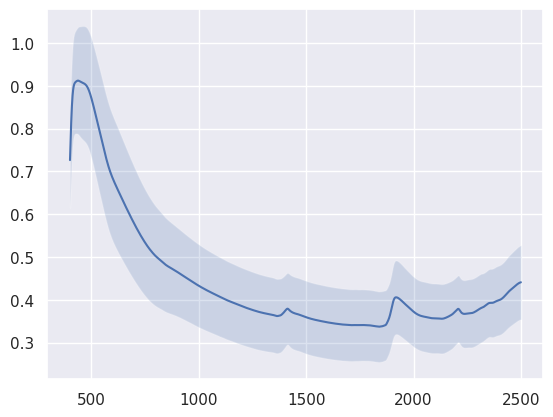

In [50]:
plt.fill_between(src_x, df.mean()+df.std(), df.mean()-df.std(),alpha=0.2)
plt.plot(src_x, df.mean())